# Authors

- David Robredo Manuel
- Duarte Novas Álvarez
- Rubén González Braña

## Imports

In [ ]:
import tensorflow as tf
import keras
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import kagglehub

from keras.callbacks import EarlyStopping

from keras.utils import to_categorical

2025-03-06 15:53:49.535491: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-03-06 15:53:49.553809: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1741272829.571441 3058900 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1741272829.576876 3058900 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-03-06 15:53:49.594432: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

In [ ]:
print("Available Physical Devices: ", tf.config.list_physical_devices())

Available Physical Devices:  [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Functions

In [ ]:
def show_image(image):

    plt.imshow(image)
    plt.axis("off")
    plt.show()

## Preprocessing

#### LOADING DATA

In [ ]:
# Download latest version
path = kagglehub.dataset_download("pritpal2873/multiple-skin-disease-detection-and-classification")

print("Path to dataset files:", path)

Show an example image of the dataset

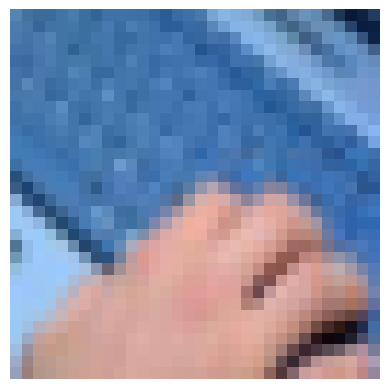

In [ ]:
show_image(X_train[10])

In [ ]:
y_train = y_train.flatten()
y_test = y_test.flatten()

In [ ]:
X_train = np.array(X_train)
y_train = np.array(y_train)
X_test = np.array(X_test)
y_test = np.array(y_test)

We apply one hot encoding to the target labels

In [ ]:
y_train = to_categorical(y_train, num_classes=20)
y_test = to_categorical(y_test, num_classes=20)

In [ ]:
len(X_train), len(y_train), len(X_test), len(y_test)

(50000, 50000, 10000, 10000)

## Models

### Model 1

#### Creation

We define an augmentation layer that will increase artificially the number of input images, to avoid overfitting, with a random rotation and zoom

In [ ]:
data_augmentation_layer_1 = keras.Sequential(
    [
        keras.layers.RandomFlip("horizontal"),
        keras.layers.RandomRotation(0.1),
        keras.layers.RandomZoom(0.2),
    ]
)

Then we define the architecture of the first model, with a rescaling layer to put all the pixel values in the range [0,1], several convolutional layers, a pooling layer and the a flatten layer. Finally, we apply dropout in order to avoid overfitting. The ouput layer is a Dense layer with 20 units, because we have 20 output classes.

In [ ]:
inputs = keras.Input(shape=(32, 32, 3, ))

x = data_augmentation_layer_1(inputs)

x = keras.layers.Rescaling(1./255)(x)
x = keras.layers.Conv2D(filters=32, kernel_size=3, activation="relu")(x)
x = keras.layers.MaxPooling2D(pool_size=2)(x)
x = keras.layers.Conv2D(filters=64, kernel_size=3, activation="relu")(x)
x = keras.layers.Flatten()(x)
x = keras.layers.Dropout(0.4)(x)

outputs = keras.layers.Dense(20, activation="softmax")(x)
model_1 = keras.Model(inputs = inputs, outputs = outputs)
model_1.summary()

Model: "functional_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)     │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_4 (Sequential)       │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_4 (Rescaling)         │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_108 (Conv2D)             │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_109 (Conv2D)             │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 10816)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 10816)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 20)             │       216,340 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,732 (920.83 KB)

 Trainable params: 235,732 (920.83 KB)

 Non-trainable params: 0 (0.00 B)

A visual representation of the architecture

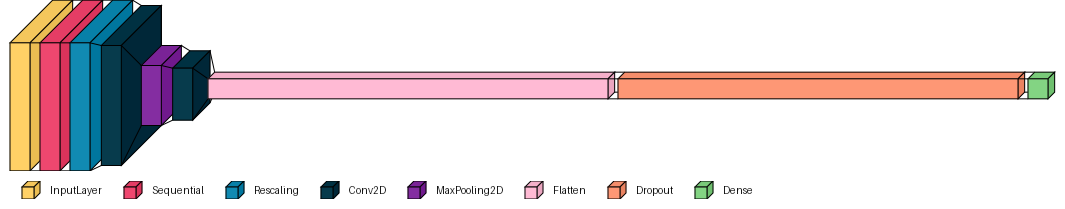

In [ ]:
visualkeras.layered_view(model_1, legend=True)

#### Compilation

We use the adam optimizer because of its adaptation to the situation

In [ ]:
model_1.compile(
    loss="categorical_crossentropy",
    optimizer="adam",
    metrics = ["accuracy"]
)

#### Tranining

We define an early stopping callback so we can end the training when the "val_loss" has not been increased in 15 epochs

In [ ]:
early_stopping_cb = EarlyStopping(patience=15, monitor="val_loss", mode="min", restore_best_weights=True)

We define a validation set of 20% of the total data

In [ ]:
history_model_1 = model_1.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=200,
    callbacks=[early_stopping_cb]
)

Epoch 1/200
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.2081 - loss: 2.5779 - val_accuracy: 0.3376 - val_loss: 2.1707
Epoch 2/200
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.3176 - loss: 2.2315 - val_accuracy: 0.3716 - val_loss: 2.0506
Epoch 3/200
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.3491 - loss: 2.1137 - val_accuracy: 0.3744 - val_loss: 2.0635
Epoch 4/200
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.3709 - loss: 2.0466 - val_accuracy: 0.4175 - val_loss: 1.9104
Epoch 5/200
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.3884 - loss: 1.9980 - val_accuracy: 0.4180 - val_loss: 1.9150
Epoch 6/200
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.3880 - loss: 1.9821 - val_accuracy: 0.3897 - val_loss: 2.0082
Epoch 7/200
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4085 - loss: 1.9300 - val_accuracy: 0.4298 - val_loss: 1.8865
Epoch 8/200
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4097 - loss: 1

In [ ]:
model_1.save("Model1.h5")

<Axes: >

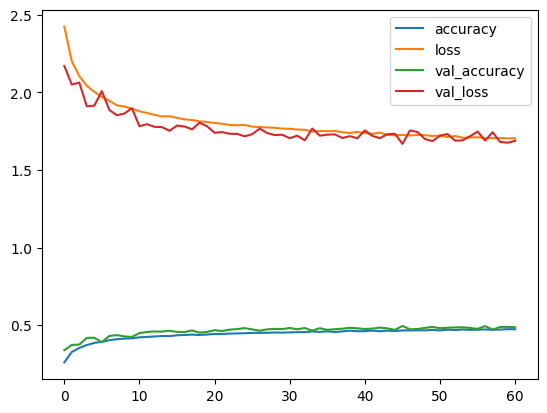

In [ ]:
pd.DataFrame(history_model_1.history).to_csv("Model1_Train_History.csv")
pd.DataFrame(history_model_1.history).plot()

#### Testing

Finally, we test the model with data that it has never seen

In [ ]:
model_1.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4980 - loss: 1.6461 


[1.6570310592651367, 0.49720001220703125]

---